In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# Define Project Paths
# ============================================================

DATA_PATH = "../data/processed/cleaned_advertising.csv"
PROCESSED_DATA_DIR = "../data/processed"
MODEL_DIR = "../models"

os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("Project directories verified.")

Project directories verified.


In [3]:
# ============================================================
# Load Cleaned Dataset
# ============================================================

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
display(df.head())

Dataset loaded successfully.


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
# ============================================================
# Dataset Overview
# ============================================================

print(f"Number of rows    : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")

display(df.head())

Number of rows    : 200
Number of columns : 4


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [5]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [6]:
# Statistical summary

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,15.1305,5.283892,1.6,11.000,16.00,19.050,27.0


In [7]:
# ============================================================
# Missing Value Check
# ============================================================

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().sum() / len(df) * 100
    )
})

display(
    missing_summary.style.format({
        "Missing Percentage": "{:.2f}%"
    })
)

,Missing Values,Missing Percentage
TV,0,0.00%
Radio,0,0.00%
Newspaper,0,0.00%
Sales,0,0.00%


In [8]:
# ============================================================
# Duplicate Row Check
# ============================================================

duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


In [9]:
# ============================================================
# Data Type Check
# ============================================================

data_type_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Unique Values": df.nunique().values
})

display(data_type_summary)

,Column,Data Type,Unique Values
0,TV,float64,190
1,Radio,float64,167
2,Newspaper,float64,172
3,Sales,float64,121


In [10]:
# ============================================================
# Infinite Value Check
# ============================================================

numeric_df = df.select_dtypes(include=np.number)

infinite_values = pd.DataFrame({
    "Positive Infinity": np.isposinf(numeric_df).sum(),
    "Negative Infinity": np.isneginf(numeric_df).sum()
})

display(infinite_values)

,Positive Infinity,Negative Infinity
TV,0,0
Radio,0,0
Newspaper,0,0
Sales,0,0


In [11]:
# ============================================================
# Validate Required Columns
# ============================================================

required_columns = [
    "TV",
    "Radio",
    "Newspaper",
    "Sales"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Required columns missing from dataset: {missing_columns}"
    )

print("All required columns are available.")

All required columns are available.


In [12]:
# ============================================================
# Separate Features and Target
# ============================================================

feature_columns = [
    "TV",
    "Radio",
    "Newspaper"
]

target_column = "Sales"

X = df[feature_columns].copy()
y = df[target_column].copy()

print("Feature shape:", X.shape)
print("Target shape :", y.shape)

Feature shape: (200, 3)
Target shape : (200,)


In [13]:
print("Features")
display(X.head())

print("Target")
display(y.head().to_frame())

Features


,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


Target


,Sales
0,22.1
1,10.4
2,12.0
3,16.5
4,17.9


In [14]:
# ============================================================
# Feature Summary
# ============================================================

feature_summary = X.describe().T

feature_summary["Range"] = (
    feature_summary["max"]
    - feature_summary["min"]
)

display(feature_summary)

,count,mean,std,min,25%,50%,75%,max,Range
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4,295.7
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0,113.7


In [15]:
# ============================================================
# Correlation Matrix
# ============================================================

correlation_matrix = df[
    feature_columns + [target_column]
].corr(numeric_only=True)

display(correlation_matrix.round(3))

,TV,Radio,Newspaper,Sales
TV,1.000,0.055,0.057,0.901
Radio,0.055,1.000,0.354,0.350
Newspaper,0.057,0.354,1.000,0.158
Sales,0.901,0.350,0.158,1.000


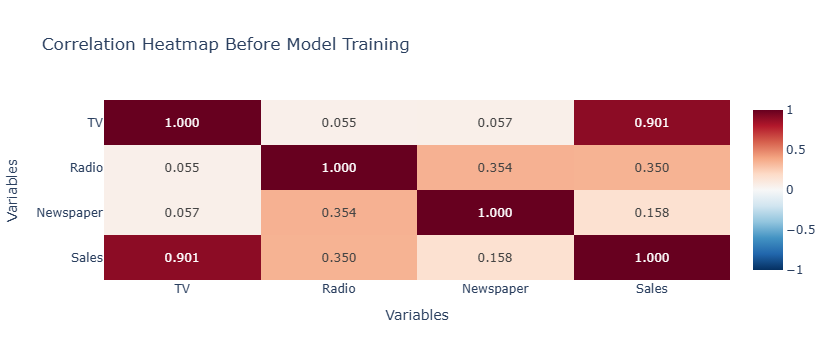

In [16]:
# ============================================================
# Interactive Correlation Heatmap
# ============================================================

fig = px.imshow(
    correlation_matrix,
    text_auto=".3f",
    aspect="auto",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Correlation Heatmap Before Model Training"
)

fig.update_layout(
    xaxis_title="Variables",
    yaxis_title="Variables"
)

fig.show()

In [17]:
# ============================================================
# Correlation of Features with Sales
# ============================================================

sales_correlations = (
    correlation_matrix[target_column]
    .drop(target_column)
    .sort_values(ascending=False)
    .reset_index()
)

sales_correlations.columns = [
    "Feature",
    "Correlation with Sales"
]

display(
    sales_correlations.style.format({
        "Correlation with Sales": "{:.3f}"
    })
)

,Feature,Correlation with Sales
0,TV,0.901
1,Radio,0.350
2,Newspaper,0.158


In [18]:
# ============================================================
# Calculate Variance Inflation Factor
# ============================================================

X_vif = X.copy()
X_vif.insert(0, "Intercept", 1.0)

vif_summary = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(
            X_vif.values,
            feature_index
        )
        for feature_index in range(X_vif.shape[1])
    ]
})

# The intercept VIF is not used to evaluate predictor
# multicollinearity.
vif_summary = vif_summary[
    vif_summary["Feature"] != "Intercept"
].reset_index(drop=True)

display(
    vif_summary.style.format({
        "VIF": "{:.3f}"
    })
)

,Feature,VIF
0,TV,1.005
1,Radio,1.145
2,Newspaper,1.145


In [19]:
# ============================================================
# VIF Interpretation
# ============================================================

def interpret_vif(vif_value):
    if vif_value < 5:
        return "Acceptable"
    elif vif_value < 10:
        return "Possible concern"
    return "High multicollinearity"

vif_summary["Interpretation"] = (
    vif_summary["VIF"].apply(interpret_vif)
)

display(
    vif_summary.style.format({
        "VIF": "{:.3f}"
    })
)

,Feature,VIF,Interpretation
0,TV,1.005,Acceptable
1,Radio,1.145,Acceptable
2,Newspaper,1.145,Acceptable


In [20]:
# ============================================================
# Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape :", X_test.shape)
print("Training target shape :", y_train.shape)
print("Testing target shape  :", y_test.shape)

Training feature shape: (160, 3)
Testing feature shape : (40, 3)
Training target shape : (160,)
Testing target shape  : (40,)


In [21]:
# ============================================================
# Train-Test Summary
# ============================================================

split_summary = pd.DataFrame({
    "Dataset": [
        "Training Set",
        "Testing Set"
    ],
    "Rows": [
        len(X_train),
        len(X_test)
    ],
    "Percentage": [
        len(X_train) / len(X) * 100,
        len(X_test) / len(X) * 100
    ]
})

display(
    split_summary.style.format({
        "Percentage": "{:.1f}%"
    })
)

,Dataset,Rows,Percentage
0,Training Set,160,80.0%
1,Testing Set,40,20.0%


In [22]:
# ============================================================
# Prepare Target Distribution Data
# ============================================================

train_target_df = pd.DataFrame({
    "Sales": y_train.reset_index(drop=True),
    "Dataset": "Training"
})

test_target_df = pd.DataFrame({
    "Sales": y_test.reset_index(drop=True),
    "Dataset": "Testing"
})

target_distribution_df = pd.concat(
    [train_target_df, test_target_df],
    ignore_index=True
)

display(target_distribution_df.head())

,Sales,Dataset
0,11.0,Training
1,14.8,Training
2,10.1,Training
3,9.7,Training
4,16.6,Training


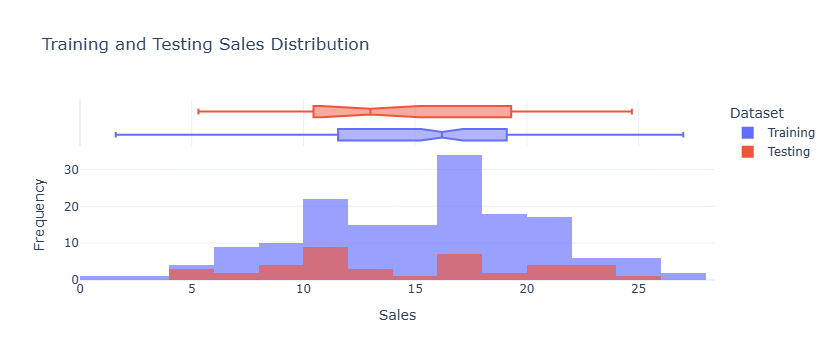

In [23]:
# ============================================================
# Interactive Target Distribution Comparison
# ============================================================

fig = px.histogram(
    target_distribution_df,
    x="Sales",
    color="Dataset",
    nbins=20,
    barmode="overlay",
    opacity=0.65,
    marginal="box",
    title="Training and Testing Sales Distribution",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Sales",
    yaxis_title="Frequency"
)

fig.show()

In [24]:
# ============================================================
# Target Statistics Comparison
# ============================================================

target_statistics = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Median",
        "Standard Deviation",
        "Minimum",
        "Maximum"
    ],
    "Training": [
        y_train.mean(),
        y_train.median(),
        y_train.std(),
        y_train.min(),
        y_train.max()
    ],
    "Testing": [
        y_test.mean(),
        y_test.median(),
        y_test.std(),
        y_test.min(),
        y_test.max()
    ]
})

display(
    target_statistics.style.format({
        "Training": "{:.3f}",
        "Testing": "{:.3f}"
    })
)

,Statistic,Training,Testing
0,Mean,15.331,14.330
1,Median,16.200,13.000
2,Standard Deviation,5.193,5.630
3,Minimum,1.600,5.300
4,Maximum,27.000,24.700


In [25]:
# ============================================================
# Reset Indices
# ============================================================

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Dataset indices reset successfully.")

Dataset indices reset successfully.


In [26]:
# ============================================================
# Fit Scaler on Training Data
# ============================================================

scaler = StandardScaler()

X_train_scaled_array = scaler.fit_transform(X_train)
X_test_scaled_array = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [27]:
# ============================================================
# Convert Scaled Arrays to DataFrames
# ============================================================

X_train_scaled = pd.DataFrame(
    X_train_scaled_array,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled_array,
    columns=X_test.columns
)

display(X_train_scaled.head())

,TV,Radio,Newspaper
0,-0.404248,-1.028237,-0.337675
1,0.320608,-0.919828,-1.161439
2,-1.270511,0.259124,0.254251
3,-1.042359,-0.696233,-0.574446
4,0.879103,-1.387343,-0.707629


In [28]:
# ============================================================
# Verify Training Data Scaling
# ============================================================

scaling_verification = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Scaled Mean": X_train_scaled.mean().values,
    "Scaled Standard Deviation": (
        X_train_scaled.std(ddof=0).values
    )
})

display(
    scaling_verification.style.format({
        "Scaled Mean": "{:.6f}",
        "Scaled Standard Deviation": "{:.6f}"
    })
)

,Feature,Scaled Mean,Scaled Standard Deviation
0,TV,-0.000000,1.000000
1,Radio,-0.000000,1.000000
2,Newspaper,0.000000,1.000000


In [29]:
# ============================================================
# Save Unscaled Feature Datasets
# ============================================================

X_train.to_csv(
    os.path.join(
        PROCESSED_DATA_DIR,
        "X_train.csv"
    ),
    index=False
)

X_test.to_csv(
    os.path.join(
        PROCESSED_DATA_DIR,
        "X_test.csv"
    ),
    index=False
)

print("Unscaled feature datasets saved successfully.")

Unscaled feature datasets saved successfully.


In [30]:
# ============================================================
# Save Scaled Feature Datasets
# ============================================================

X_train_scaled.to_csv(
    os.path.join(
        PROCESSED_DATA_DIR,
        "X_train_scaled.csv"
    ),
    index=False
)

X_test_scaled.to_csv(
    os.path.join(
        PROCESSED_DATA_DIR,
        "X_test_scaled.csv"
    ),
    index=False
)

print("Scaled feature datasets saved successfully.")

Scaled feature datasets saved successfully.


In [31]:
# ============================================================
# Save Target Datasets
# ============================================================

y_train.to_frame(name="Sales").to_csv(
    os.path.join(
        PROCESSED_DATA_DIR,
        "y_train.csv"
    ),
    index=False
)

y_test.to_frame(name="Sales").to_csv(
    os.path.join(
        PROCESSED_DATA_DIR,
        "y_test.csv"
    ),
    index=False
)

print("Target datasets saved successfully.")

Target datasets saved successfully.


In [32]:
# ============================================================
# Save Fitted Scaler
# ============================================================

SCALER_PATH = os.path.join(
    MODEL_DIR,
    "scaler.pkl"
)

joblib.dump(
    scaler,
    SCALER_PATH
)

print(f"Scaler saved successfully at: {SCALER_PATH}")

Scaler saved successfully at: ../models\scaler.pkl


In [33]:
# ============================================================
# Save Preprocessing Metadata
# ============================================================

preprocessing_metadata = {
    "feature_columns": feature_columns,
    "target_column": target_column,
    "test_size": 0.20,
    "random_state": 42,
    "scaler": "StandardScaler"
}

METADATA_PATH = os.path.join(
    MODEL_DIR,
    "preprocessing_metadata.pkl"
)

joblib.dump(
    preprocessing_metadata,
    METADATA_PATH
)

print(
    "Preprocessing metadata saved successfully at:",
    METADATA_PATH
)

Preprocessing metadata saved successfully at: ../models\preprocessing_metadata.pkl


In [34]:
# ============================================================
# Verify Processed Data Files
# ============================================================

expected_data_files = [
    "cleaned_advertising.csv",
    "X_train.csv",
    "X_test.csv",
    "X_train_scaled.csv",
    "X_test_scaled.csv",
    "y_train.csv",
    "y_test.csv"
]

data_file_verification = pd.DataFrame({
    "File": expected_data_files,
    "Saved": [
        os.path.exists(
            os.path.join(
                PROCESSED_DATA_DIR,
                filename
            )
        )
        for filename in expected_data_files
    ]
})

display(data_file_verification)

,File,Saved
0,cleaned_advertising.csv,True
1,X_train.csv,True
2,X_test.csv,True
3,X_train_scaled.csv,True
4,X_test_scaled.csv,True
5,y_train.csv,True
6,y_test.csv,True


In [35]:
# ============================================================
# Verify Model Files
# ============================================================

expected_model_files = [
    "scaler.pkl",
    "preprocessing_metadata.pkl"
]

model_file_verification = pd.DataFrame({
    "File": expected_model_files,
    "Saved": [
        os.path.exists(
            os.path.join(
                MODEL_DIR,
                filename
            )
        )
        for filename in expected_model_files
    ]
})

display(model_file_verification)

,File,Saved
0,scaler.pkl,True
1,preprocessing_metadata.pkl,True


In [36]:
# ============================================================
# Reload Saved Files for Validation
# ============================================================

saved_X_train = pd.read_csv(
    os.path.join(
        PROCESSED_DATA_DIR,
        "X_train.csv"
    )
)

saved_X_test = pd.read_csv(
    os.path.join(
        PROCESSED_DATA_DIR,
        "X_test.csv"
    )
)

saved_y_train = pd.read_csv(
    os.path.join(
        PROCESSED_DATA_DIR,
        "y_train.csv"
    )
)

saved_y_test = pd.read_csv(
    os.path.join(
        PROCESSED_DATA_DIR,
        "y_test.csv"
    )
)

print("Saved X_train shape:", saved_X_train.shape)
print("Saved X_test shape :", saved_X_test.shape)
print("Saved y_train shape:", saved_y_train.shape)
print("Saved y_test shape :", saved_y_test.shape)

Saved X_train shape: (160, 3)
Saved X_test shape : (40, 3)
Saved y_train shape: (160, 1)
Saved y_test shape : (40, 1)


In [37]:
# ============================================================
# Validate Feature-Target Alignment
# ============================================================

assert len(saved_X_train) == len(saved_y_train), (
    "Training feature and target lengths do not match."
)

assert len(saved_X_test) == len(saved_y_test), (
    "Testing feature and target lengths do not match."
)

assert saved_X_train.columns.tolist() == feature_columns, (
    "Saved training feature order is incorrect."
)

assert saved_X_test.columns.tolist() == feature_columns, (
    "Saved testing feature order is incorrect."
)

print("All saved datasets passed validation.")

All saved datasets passed validation.


In [38]:
# ============================================================
# Preprocessing Summary
# ============================================================

preprocessing_summary = pd.DataFrame({
    "Step": [
        "Required columns validated",
        "Missing values checked",
        "Duplicate rows checked",
        "Infinite values checked",
        "Features and target separated",
        "Correlation validated",
        "Multicollinearity assessed",
        "Train-test split completed",
        "Target distributions compared",
        "Unscaled datasets saved",
        "Scaled datasets saved",
        "Scaler saved",
        "Metadata saved",
        "Saved datasets validated"
    ],
    "Status": ["Completed"] * 14
})

display(preprocessing_summary)

,Step,Status
0,Required columns validated,Completed
1,Missing values checked,Completed
2,Duplicate rows checked,Completed
3,Infinite values checked,Completed
4,Features and target separated,Completed
5,Correlation validated,Completed
6,Multicollinearity assessed,Completed
7,Train-test split completed,Completed
8,Target distributions compared,Completed
9,Unscaled datasets saved,Completed
